# 00 — Model output overview

Use this notebook first. It checks the latest model outputs, summarizes the key datasets, and gives a quick comparison of observed rates, frequentist predictions, Bayesian predictions, and Bayesian spatial predictions.

In [2]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# This lets the notebook work whether it is launched from the project root or from notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUTS = PROJECT_ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)


def read_json(path):
    path = Path(path)
    if not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing expected file: {path}")
    return path


def load_csv(relative_path, **kwargs):
    path = require_file(OUTPUTS / relative_path)
    return pd.read_csv(path, **kwargs)


def savefig(name):
    path = FIGURES / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved figure: {path}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs folder: {OUTPUTS}")


Project root: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project
Outputs folder: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs


## Load metadata and validation results

In [3]:

metadata = read_json(OUTPUTS / "run_metadata.json")
validation = read_json(OUTPUTS / "validation_report.json")

summary_keys = [
    "scope", "n_polygon_areas", "n_rows_after_all_polygon_retention",
    "n_rows_used_in_likelihood", "n_rows_predicted", "population_column",
    "population_denominator_type", "population_total_modeled",
    "model_type", "requested_bootstrap_fits", "successful_bootstrap_fits",
]
metadata_summary = {k: metadata.get(k) for k in summary_keys if k in metadata}
pd.DataFrame.from_dict(metadata_summary, orient="index", columns=["value"])


,value
scope,slp
n_polygon_areas,58
n_rows_after_all_polygon_retention,58
n_rows_used_in_likelihood,57
n_rows_predicted,58
population_column,pobfem
population_denominator_type,female_population
population_total_modeled,1449804.0
model_type,discrete_negative_binomial_estimated_dispersion
requested_bootstrap_fits,100


In [4]:

# Validation report structure varies slightly by version, so this handles both common forms.
checks = validation.get("checks", [])
if isinstance(checks, dict):
    checks_df = pd.DataFrame([{"check": k, **(v if isinstance(v, dict) else {"value": v})} for k, v in checks.items()])
else:
    checks_df = pd.DataFrame(checks)

if not checks_df.empty:
    display(checks_df.head(20))
    if "passed" in checks_df.columns:
        print("Passed:", int(checks_df["passed"].sum()), "of", len(checks_df))
        display(checks_df[~checks_df["passed"]])
else:
    print("No validation checks table found; showing raw validation JSON keys:", validation.keys())


,check,passed,detail
0,analytic_dataset_exists,True,outputs/analytic_dataset.csv
1,modeled_dataset_exists,True,outputs/modeled_dataset.csv
2,run_metadata_exists,True,outputs/run_metadata.json
3,feature_filter_report_exists,True,outputs/feature_filter_report.csv
4,ranking_stability_exists,True,outputs/ranking_stability.csv
5,risk_map_exists,True,outputs/risk_map.geojson
6,missing_outcome_report_exists,True,outputs/missing_outcome_geos.csv
7,single_family_sensitivity_exists,True,outputs/sensitivity_single_family_metrics.csv
8,bayesian_input_exists,True,outputs/bayesian_nb_input.csv
9,bayesian_config_exists,True,outputs/bayesian_model_config.json


Passed: 67 of 67


,check,passed,detail


## Load the core output tables

In [5]:

modeled = load_csv("modeled_dataset.csv")
model_summary = load_csv("model_summary.csv")
ranking = load_csv("ranking_stability.csv")
bayes_nb = load_csv("bayes/bayesian_nb_posterior_rates.csv")
bayes_spatial = load_csv("bayes_spatial/bayesian_spatial_posterior_rates.csv")
bayes_topk = load_csv("bayes_spatial/bayesian_spatial_top_k_probabilities.csv")

# Keep IDs consistent for merging/display.
for df in [modeled, ranking, bayes_nb, bayes_spatial, bayes_topk]:
    df["geo_id"] = df["geo_id"].astype(str)

combined = modeled.merge(ranking, on="geo_id", how="left") \
    .merge(bayes_nb, on="geo_id", how="left") \
    .merge(bayes_spatial, on="geo_id", how="left") \
    .merge(bayes_topk[["geo_id", "bayes_spatial_top_k_probability"]], on="geo_id", how="left")

print("modeled:", modeled.shape)
print("model_summary:", model_summary.shape)
print("combined:", combined.shape)
combined.head()


modeled: (58, 33)
model_summary: (15, 10)
combined: (58, 45)


,geo_id,population,age_share_female_60plus,age_share_female_15_49,outcome_count,outcome_missing_flag,ambientalagua_kernel_intensity,ambientalagua_nearest_source_m,ambientalagua_count_within_1000m,ambientalagua_count_within_5000m,ambientalagua_count_within_10000m,ambientalladrilleras_kernel_intensity,ambientalladrilleras_nearest_source_m,ambientalladrilleras_count_within_1000m,ambientalladrilleras_count_within_5000m,ambientalladrilleras_count_within_10000m,ambientalminasmetales_kernel_intensity,ambientalminasmetales_nearest_source_m,ambientalminasmetales_count_within_1000m,ambientalminasmetales_count_within_5000m,ambientalminasmetales_count_within_10000m,ambientalretc_kernel_intensity,ambientalretc_nearest_source_m,ambientalretc_count_within_1000m,ambientalretc_count_within_5000m,ambientalretc_count_within_10000m,observed_rate_per_100k,control_age_share_female_60plus_z,control_age_share_female_15_49_z,model_inclusion_flag,outcome_count_for_model,predicted_count,predicted_rate_per_100k,top_k_selection_probability,successful_bootstrap_fits,requested_bootstrap_fits,ranking_stability_method,bayes_predicted_rate_mean_per_100k,bayes_predicted_rate_ci_lower,bayes_predicted_rate_ci_upper,bayes_spatial_predicted_rate_mean_per_100k,bayes_spatial_predicted_rate_ci_lower,bayes_spatial_predicted_rate_ci_upper,bayes_spatial_predicted_count_mean,bayes_spatial_top_k_probability
0,24042,6875,0.164218,0.470255,4.0,0,0.000332,80426.700938,0,0,0,0.000985,56142.002557,0,0,0,0.000010,266142.228641,0,0,0,0.014510,34384.531902,0,0,0,58.181818,0.416235,-0.617307,1,4.0,4.275952,62.195670,0.00,100,100,asymptotic_coefficient_draws,66.018990,45.763430,92.187002,66.922457,42.658086,100.303335,4.600919,0.0000
1,24046,9213,0.107348,0.510474,6.0,0,0.001109,33805.402043,0,0,0,0.006137,13290.559143,0,0,0,0.000038,41240.709068,0,0,0,0.043024,33717.331799,0,0,0,65.125366,-1.224831,0.860581,1,6.0,4.702577,51.042844,0.00,100,100,asymptotic_coefficient_draws,54.528464,28.542167,95.371395,56.051418,26.493547,104.277738,5.164017,0.0035
2,24002,3998,0.163082,0.469985,3.0,0,0.000598,52086.944625,0,0,0,0.002092,51118.762045,0,0,0,0.000016,151286.155630,0,0,0,0.019033,41420.283704,0,0,0,75.037519,0.383436,-0.627212,1,3.0,3.347939,83.740340,0.00,100,100,asymptotic_coefficient_draws,85.422450,65.710767,108.097141,87.563060,59.243861,125.470751,3.500771,0.0020
3,24003,24346,0.114064,0.496221,10.0,0,0.000426,56890.558049,0,0,0,0.001305,30406.653529,0,0,0,0.000012,214441.112492,0,0,0,0.017822,26761.212430,0,0,0,41.074509,-1.031042,0.336844,1,10.0,10.957035,45.005484,0.00,100,100,asymptotic_coefficient_draws,47.195651,32.434603,66.503007,47.435454,29.824250,71.452169,11.548636,0.0000
4,24004,2016,0.222718,0.453869,3.0,0,0.001290,24286.742731,0,0,0,0.004263,36081.708186,0,0,0,0.000042,39386.244301,0,0,0,0.053282,20649.012890,0,0,0,148.809524,2.104343,-1.219397,1,3.0,3.504765,173.847453,0.94,100,100,asymptotic_coefficient_draws,178.714450,102.501638,292.796400,176.243930,94.759684,297.900651,3.553078,0.7225


## Key rate summaries

In [6]:

rate_cols = [
    "observed_rate_per_100k",
    "predicted_rate_per_100k",
    "bayes_predicted_rate_mean_per_100k",
    "bayes_spatial_predicted_rate_mean_per_100k",
]
existing_rate_cols = [c for c in rate_cols if c in combined.columns]
combined[existing_rate_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
observed_rate_per_100k,57.0,95.601287,57.260222,0.000000,59.815320,80.096115,123.644664,290.697674
predicted_rate_per_100k,58.0,99.090371,48.759119,39.879937,61.131895,87.581630,125.429250,238.516283
bayes_predicted_rate_mean_per_100k,58.0,101.633592,46.652792,44.355882,66.045181,89.127293,124.508250,249.451635
bayes_spatial_predicted_rate_mean_per_100k,58.0,102.232795,46.436037,46.086628,66.368338,87.863725,125.566194,248.338515


In [7]:

# Top municipalities by Bayesian spatial predicted risk.
top_cols = [
    "geo_id", "population", "outcome_count", "observed_rate_per_100k",
    "predicted_rate_per_100k", "bayes_spatial_predicted_rate_mean_per_100k",
    "bayes_spatial_predicted_rate_ci_lower", "bayes_spatial_predicted_rate_ci_upper",
    "bayes_spatial_top_k_probability", "model_inclusion_flag",
]
top_cols = [c for c in top_cols if c in combined.columns]
combined.sort_values("bayes_spatial_predicted_rate_mean_per_100k", ascending=False)[top_cols].head(15)


,geo_id,population,outcome_count,observed_rate_per_100k,predicted_rate_per_100k,bayes_spatial_predicted_rate_mean_per_100k,bayes_spatial_predicted_rate_ci_lower,bayes_spatial_predicted_rate_ci_upper,bayes_spatial_top_k_probability,model_inclusion_flag
46,24030,2408,7.0,290.697674,238.516283,248.338515,116.001889,498.485006,0.9255,1
48,24028,471011,1244.0,264.112728,229.457538,224.241130,115.928737,417.007853,0.8720,1
51,24024,50900,78.0,153.241650,160.773609,207.569296,78.857575,524.876593,0.6750,1
6,24019,2723,5.0,183.621006,206.114261,204.013119,107.036627,341.550679,0.8560,1
4,24004,2016,3.0,148.809524,173.847453,176.243930,94.759684,297.900651,0.7225,1
29,24043,4246,5.0,117.757890,184.928521,168.000306,91.621851,277.429416,0.7150,1
9,24045,7172,11.0,153.374233,191.541881,158.133258,68.605966,316.363531,0.5050,1
28,24013,93009,190.0,204.281306,165.010567,153.388831,91.664336,254.158847,0.5330,1
20,24051,7803,15.0,192.233756,153.731199,150.128881,89.098748,242.248463,0.5195,1
56,24047,4646,3.0,64.571675,150.294185,142.503227,81.661856,223.633892,0.4430,1


## Observed vs predicted rates

Saved figure: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs\figures\00_observed_vs_bayes_spatial.png


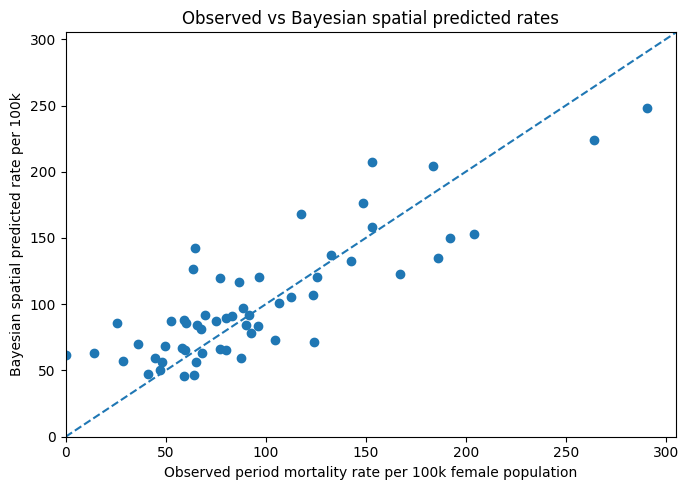

In [8]:

fig, ax = plt.subplots(figsize=(7, 5))
plot_df = combined.dropna(subset=["observed_rate_per_100k", "bayes_spatial_predicted_rate_mean_per_100k"])
ax.scatter(plot_df["observed_rate_per_100k"], plot_df["bayes_spatial_predicted_rate_mean_per_100k"])
ax.set_xlabel("Observed period mortality rate per 100k female population")
ax.set_ylabel("Bayesian spatial predicted rate per 100k")
ax.set_title("Observed vs Bayesian spatial predicted rates")
lims = [0, max(plot_df["observed_rate_per_100k"].max(), plot_df["bayes_spatial_predicted_rate_mean_per_100k"].max()) * 1.05]
ax.plot(lims, lims, linestyle="--")
ax.set_xlim(lims)
ax.set_ylim(lims)
savefig("00_observed_vs_bayes_spatial.png")
plt.show()


## Compare frequentist, non-spatial Bayesian, and spatial Bayesian predictions

In [9]:

compare_cols = [
    "predicted_rate_per_100k",
    "bayes_predicted_rate_mean_per_100k",
    "bayes_spatial_predicted_rate_mean_per_100k",
]
compare_cols = [c for c in compare_cols if c in combined.columns]
combined[compare_cols].corr()


,predicted_rate_per_100k,bayes_predicted_rate_mean_per_100k,bayes_spatial_predicted_rate_mean_per_100k
predicted_rate_per_100k,1.000000,0.973401,0.97382
bayes_predicted_rate_mean_per_100k,0.973401,1.000000,0.99820
bayes_spatial_predicted_rate_mean_per_100k,0.973820,0.998200,1.00000


Saved figure: c:\Users\zacwr\OneDrive\XD\Projects\math-seminar\sana_project\outputs\figures\00_predicted_rate_distributions.png


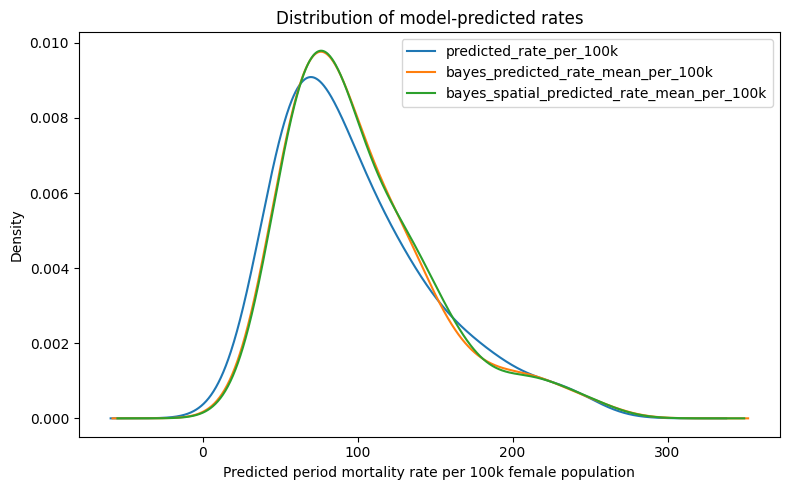

In [10]:

fig, ax = plt.subplots(figsize=(8, 5))
for col in compare_cols:
    combined[col].dropna().plot(kind="density", ax=ax, label=col)
ax.set_xlabel("Predicted period mortality rate per 100k female population")
ax.set_title("Distribution of model-predicted rates")
ax.legend()
savefig("00_predicted_rate_distributions.png")
plt.show()


## Interpretation reminder

Use the rates as **period-level mortality rates per 100,000 female population**, not annual rates, unless the mortality data are later normalized by year. Exposure terms are exploratory associations, not causal effects.